# FNO Channel Design v4 — Correct

## Diagnosis of v3

| Channel | Problem | Root cause |
|---|---|---|
| Ch1 Bandpass | Ringing / grid artifacts | Hard rectangular freq mask → Gibbs phenomenon |
| Ch2 Azimuthal asymmetry | Identical concentric rings all classes | Bug: painting whole ring with same scalar std → 1D function mapped to 2D, not spatially informative |
| Ch3 Radial deviation | ✅ working | — |

## Fixes

**Ch1 → Gaussian bandpass**: Replace hard mask with smooth Gaussian weight centred at mid-frequency. No sharp edges = no ringing.

**Ch2 → Angular gradient** `|dI/dθ|`: How fast intensity changes as you move around a ring.
- no_sub: smooth ring → near-zero angular gradient everywhere  
- subhalo: one bright point → sharp spike at the subhalo angular position  
- vortex: arc brightness varies → distributed angular gradient around the ring  
This is per-pixel and spatially localised — exactly what was missing.

## Transform fix

**Problem:** Current pipeline:
```
raw → compute Ch1-Ch3 → geometric aug (flip/rotate) → normalize → RandomErasing all channels
```
**Wrong because:**
1. Symmetry channels computed on unaugmented image, then geometrically distorted — inconsistent
2. RandomErasing applied to Ch2/Ch3 destroys physical meaning of symmetry maps

**Correct pipeline:**
```
raw → geometric aug (flip/rotate/affine) → recompute Ch1-Ch3 on augmented raw → normalize → RandomErasing Ch0 only
```


In [1]:
import numpy as np
import os
import torch
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms.functional as TF
import torchvision.transforms as transforms
import torch.nn.functional as F
import random

class LensDatasetFNO(Dataset):
    """
    FNO-optimised 4-channel input (v4 — correct):

    Ch 0 — Raw image           (spatial flux)
    Ch 1 — Gaussian bandpass   (smooth mid-freq energy — no ringing)
    Ch 2 — Angular gradient    (|dI/dθ| per pixel — substructure angular position)
    Ch 3 — Radial deviation    (|I - ring_mean| per pixel — confirmed working)

    Transform pipeline (corrected):
      1. Geometric augmentation applied to RAW image only
      2. Ch1-Ch3 computed from augmented raw → physically consistent
      3. Normalize all 4 channels
      4. RandomErasing on Ch0 only → doesn't corrupt symmetry channels
    """
    def __init__(self, root_dir, mean=None, std=None, augment=False):
        self.root_dir = root_dir
        self.augment  = augment
        self.mean     = mean   # list of 4 floats, or None
        self.std      = std

        self.paths, self.labels = [], []
        self.classes = sorted([d for d in os.listdir(root_dir)
                                if os.path.isdir(os.path.join(root_dir, d))])
        self.class_to_idx = {cls: i for i, cls in enumerate(self.classes)}
        for cls in self.classes:
            for f in sorted(os.listdir(os.path.join(root_dir, cls))):
                if f.endswith(".npy"):
                    self.paths.append(os.path.join(root_dir, cls, f))
                    self.labels.append(self.class_to_idx[cls])

    def __len__(self): return len(self.paths)

    # ── Step 1: geometric augmentation on raw image ──────────────────────────

    def _geometric_aug(self, img):
        """Apply physics-valid geometric augmentations to raw (1,H,W) tensor.
        Lensing is invariant to rotation and reflection — all transforms valid."""
        if random.random() > 0.5: img = TF.hflip(img)
        if random.random() > 0.5: img = TF.vflip(img)
        angle = random.uniform(-180, 180)
        img = TF.rotate(img, angle, fill=0)
        # small translation (5%)
        H, W = img.shape[-2], img.shape[-1]
        tx = int(random.uniform(-0.05, 0.05) * W)
        ty = int(random.uniform(-0.05, 0.05) * H)
        img = TF.affine(img, angle=0, translate=[tx, ty], scale=1.0, shear=0, fill=0)
        return img

    # ── Step 2: channel computation on (possibly augmented) raw ──────────────

    def _gaussian_bandpass(self, img):
        """
        Ch 1: Smooth Gaussian bandpass centred at mid-frequency.

        Uses a Gaussian weight in Fourier space:
            W(R) = exp(-(R - R0)^2 / (2*sigma^2))
        where R is normalised radial frequency, R0=0.15 is mid-band centre.

        No hard edges → no Gibbs/ringing artifacts.
        The filtered image is reconstructed via irfft2.

        Subhalo  → concentrated bright spot (mid-freq energy at arc location)
        Vortex   → distributed mid-freq energy around ring
        no_sub   → near-uniform, low mid-freq energy
        """
        eps = 1e-8
        H, W = img.shape[-2], img.shape[-1]
        ft = torch.fft.rfft2(img[0], norm="ortho")  # (H, W//2+1)

        fy = torch.fft.fftfreq(H)
        fx = torch.fft.rfftfreq(W)
        FY, FX = torch.meshgrid(fy, fx, indexing='ij')
        R = torch.sqrt(FY**2 + FX**2)

        # Gaussian bandpass: centre=0.15, width=0.07
        R0, sigma = 0.15, 0.07
        gauss_weight = torch.exp(-((R - R0)**2) / (2 * sigma**2))

        filtered = torch.fft.irfft2(ft * gauss_weight, s=(H, W), norm="ortho")
        filtered = filtered.abs()
        return ((filtered - filtered.min()) / (filtered.max() - filtered.min() + eps)).unsqueeze(0)

    def _angular_gradient(self, img):
        """
        Ch 2: Per-pixel angular gradient |dI/dθ| in polar coordinates.

        For each pixel at (r, θ), measures how fast intensity changes
        as you move around the ring at that radius.

        Computed by:
          1. Build angle map θ(x,y) = atan2(y-cy, x-cx)
          2. Approximate dI/dθ via finite differences along the angular direction
             using bilinear sampling at (r, θ±Δθ)

        Result:
          no_sub  → smooth ring → near-zero |dI/dθ| everywhere
          subhalo → one bright spot → sharp spike at the angular position of subhalo
          vortex  → arc brightness variation → distributed angular gradient

        This is spatially localised — each pixel gets its own value, not a ring-average.
        """
        eps = 1e-8
        H, W = img.shape[-2], img.shape[-1]
        cx, cy = (W - 1) / 2.0, (H - 1) / 2.0

        ys = torch.arange(H, dtype=torch.float32).unsqueeze(1).expand(H, W)
        xs = torch.arange(W, dtype=torch.float32).unsqueeze(0).expand(H, W)

        radii  = torch.sqrt((xs - cx)**2 + (ys - cy)**2).clamp(min=1.0)
        angles = torch.atan2(ys - cy, xs - cx)   # (H, W), range [-pi, pi]

        dtheta = 0.15  # ~8.6 degrees step

        # sample points at θ+dθ and θ-dθ on the same radius
        def polar_to_grid(r, theta):
            """Convert polar (r,θ) to normalised grid coords for grid_sample."""
            x = cx + r * torch.cos(theta)
            y = cy + r * torch.sin(theta)
            # normalise to [-1, 1] for grid_sample
            gx = (x / (W - 1)) * 2 - 1
            gy = (y / (H - 1)) * 2 - 1
            return torch.stack([gx, gy], dim=-1)   # (H, W, 2)

        grid_plus  = polar_to_grid(radii, angles + dtheta)
        grid_minus = polar_to_grid(radii, angles - dtheta)

        I = img.unsqueeze(0)  # (1, 1, H, W) for grid_sample

        I_plus  = F.grid_sample(I, grid_plus.unsqueeze(0),
                                 mode='bilinear', padding_mode='zeros',
                                 align_corners=True).squeeze()
        I_minus = F.grid_sample(I, grid_minus.unsqueeze(0),
                                 mode='bilinear', padding_mode='zeros',
                                 align_corners=True).squeeze()

        ang_grad = (I_plus - I_minus).abs() / (2 * dtheta)
        return ((ang_grad - ang_grad.min()) /
                (ang_grad.max() - ang_grad.min() + eps)).unsqueeze(0)

    def _radial_deviation(self, img):
        """Ch 3: unchanged — confirmed working."""
        eps = 1e-8
        H, W = img.shape[-2], img.shape[-1]
        cx, cy = W / 2.0, H / 2.0
        ys = torch.arange(H, dtype=torch.float32).unsqueeze(1).expand(H, W)
        xs = torch.arange(W, dtype=torch.float32).unsqueeze(0).expand(H, W)
        radii   = torch.sqrt((xs - cx)**2 + (ys - cy)**2)
        n_bins  = 30
        bin_idx = (radii / (radii.max() + eps) * n_bins).long().clamp(0, n_bins - 1)
        I = img[0]
        dev = torch.zeros_like(I)
        for b in range(n_bins):
            mask = (bin_idx == b)
            if mask.sum() > 0:
                dev[mask] = (I[mask] - I[mask].mean()).abs()
        return ((dev - dev.min()) / (dev.max() - dev.min() + eps)).unsqueeze(0)

    def _build_channels(self, raw):
        """Build all 4 channels from raw (1,H,W) tensor."""
        return torch.cat([
            raw,
            self._gaussian_bandpass(raw),
            self._angular_gradient(raw),
            self._radial_deviation(raw),
        ], dim=0)   # (4, H, W)

    # ── Step 3: normalisation ─────────────────────────────────────────────────

    def _normalize(self, x):
        if self.mean is None: return x
        mean = torch.tensor(self.mean, dtype=torch.float32).view(-1, 1, 1)
        std  = torch.tensor(self.std,  dtype=torch.float32).view(-1, 1, 1)
        return (x - mean) / std

    def __getitem__(self, idx):
        raw = torch.tensor(np.load(self.paths[idx]), dtype=torch.float32)
        if raw.ndim == 2: raw = raw.unsqueeze(0)

        # 1. Geometric augmentation on raw only
        if self.augment:
            raw = self._geometric_aug(raw)

        # 2. Compute all channels from (augmented) raw
        x = self._build_channels(raw)       # (4, H, W)

        # 3. Normalize
        x = self._normalize(x)

        # 4. RandomErasing on Ch0 ONLY — does not corrupt symmetry channels
        if self.augment and random.random() < 0.2:
            # erase a small patch only in the raw channel
            i, j, h, w, v = transforms.RandomErasing.get_params(
                x[0:1], scale=(0.02, 0.08), ratio=(0.3, 3.3), value=[0])
            x[0, i:i+h, j:j+w] = v

        return x, self.labels[idx]


## Visualise — confirm all channels are discriminative

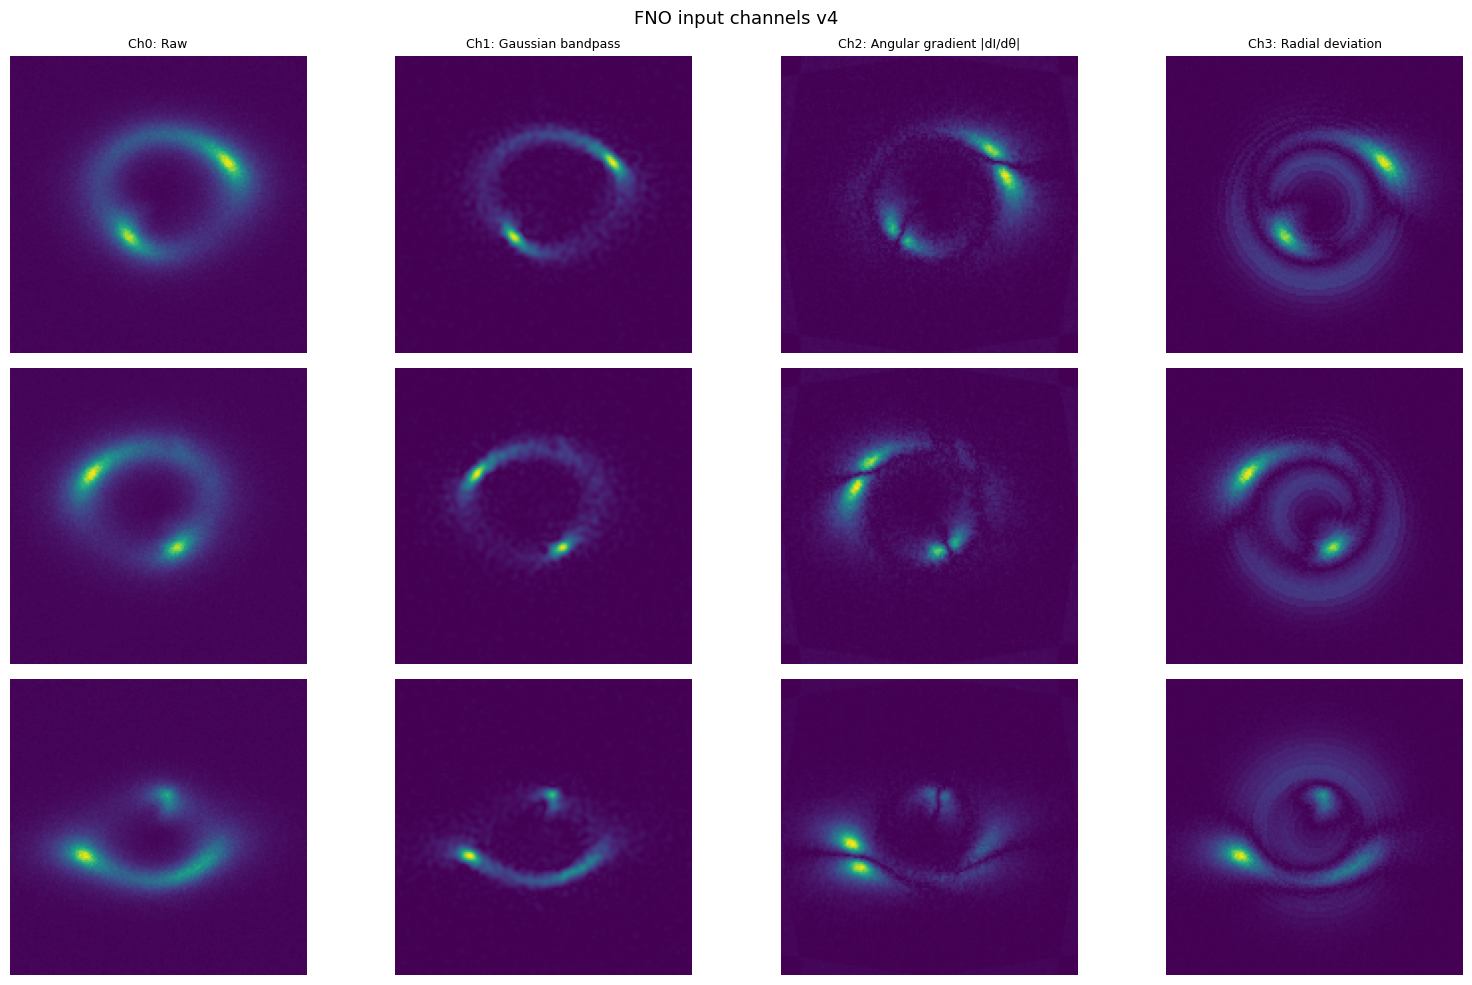

Expected per channel:
Ch1: no_sub=soft uniform glow | subhalo=bright localised blob | vortex=ring of mid-freq energy
Ch2: no_sub=near-zero         | subhalo=bright spot at angular position | vortex=bright arc edges
Ch3: no_sub=near-zero         | subhalo=bright spot                     | vortex=bright arc regions


In [2]:
import matplotlib.pyplot as plt

dataset_viz = LensDatasetFNO("dataset/train", augment=False)
class_names = ['no_sub', 'subhalo', 'vortex']
ch_names    = ['Ch0: Raw', 'Ch1: Gaussian bandpass', 'Ch2: Angular gradient |dI/dθ|', 'Ch3: Radial deviation']

fig, axes = plt.subplots(3, 4, figsize=(16, 10))
for class_idx in range(3):
    idx = dataset_viz.labels.index(class_idx)
    img, _ = dataset_viz[idx]
    for ch in range(4):
        ax = axes[class_idx][ch]
        ax.imshow(img[ch].numpy(), cmap='viridis')
        if class_idx == 0: ax.set_title(ch_names[ch], fontsize=9)
        if ch == 0:        ax.set_ylabel(class_names[class_idx], fontsize=11)
        ax.axis('off')

plt.suptitle('FNO input channels v4', fontsize=13)
plt.tight_layout()
plt.show()

print("Expected per channel:")
print("Ch1: no_sub=soft uniform glow | subhalo=bright localised blob | vortex=ring of mid-freq energy")
print("Ch2: no_sub=near-zero         | subhalo=bright spot at angular position | vortex=bright arc edges")
print("Ch3: no_sub=near-zero         | subhalo=bright spot                     | vortex=bright arc regions")


## Compute channel statistics (no augmentation, no leakage)

In [3]:
def compute_channel_stats(root_dir, n_channels=4, batch_size=64):
    """Compute per-channel mean and std from training set.
    Uses no augmentation to avoid inflated variance."""
    ds = LensDatasetFNO(root_dir, augment=False)
    loader = DataLoader(ds, batch_size=batch_size, shuffle=False, num_workers=4)
    s1 = torch.zeros(n_channels); s2 = torch.zeros(n_channels); n = 0
    for imgs, _ in loader:
        s1 += imgs.sum(dim=[0, 2, 3])
        s2 += (imgs**2).sum(dim=[0, 2, 3])
        n  += imgs.shape[0] * imgs.shape[2] * imgs.shape[3]
    mean = s1 / n
    std  = torch.sqrt((s2/n - mean**2).clamp(min=0)).clamp(min=0.0005)
    return mean.tolist(), std.tolist()

MEAN_FNO, STD_FNO = compute_channel_stats("dataset/train")
print("Mean:", [f'{m:.4f}' for m in MEAN_FNO])
print("Std :", [f'{s:.4f}' for s in STD_FNO])


Mean: ['0.0617', '0.0239', '0.0368', '0.0420']
Std : ['0.1173', '0.0797', '0.0842', '0.0869']


## Build loaders

In [ ]:
train_dataset = LensDatasetFNO("dataset/train",
                              mean=MEAN_FNO, std=STD_FNO,
                              augment=True)

val_dataset   = LensDatasetFNO("dataset/val",
                               mean=MEAN_FNO, std=STD_FNO,
                               augment=False)   # no augmentation on val

train_loader  = DataLoader(train_dataset, batch_size=32, shuffle=True,
                           num_workers=4, pin_memory=True)
val_loader    = DataLoader(val_dataset,   batch_size=32, shuffle=False,
                           num_workers=4, pin_memory=True)

# sanity check
img, label = train_dataset[0]
print(f"Shape : {img.shape}")    # (4, 150, 150)
print(f"Label : {label}")
print(f"Ch0 range: [{img[0].min():.2f}, {img[0].max():.2f}]")
print(f"Ch1 range: [{img[1].min():.2f}, {img[1].max():.2f}]")
print(f"Ch2 range: [{img[2].min():.2f}, {img[2].max():.2f}]")
print(f"Ch3 range: [{img[3].min():.2f}, {img[3].max():.2f}]")


## Summary: transform design rationale

| Augmentation | Applied to | Why |
|---|---|---|
| RandomHFlip / VFlip | Raw only, before channel comp | Lensing is reflection-invariant; channels recomputed from flipped raw → consistent |
| RandomRotation ±180° | Raw only, before channel comp | Lensing has no preferred orientation |
| RandomAffine (translate 5%) | Raw only, before channel comp | Handles off-center lenses |
| RandomErasing | Ch0 (raw) only, after channel comp | Prevents over-reliance on single spatial location; safe on raw; would destroy symmetry maps if applied to Ch2/Ch3 |
| Normalize | All 4 channels | Per-channel z-score using training-set stats |

**Key principle:** Ch1-Ch3 are deterministic functions of the raw image. Augment the raw image → recompute channels → channels are automatically consistent with the augmented geometry.
